# LNA gain measurement with ADALM-PLUTO

まずPlutoへ接続し、現在の設定を読み出して疎通を確認します。  
このプロジェクトでは2チャネルを扱うため、`adi.Pluto`ではなく`adi.ad9361`を使用します。


## 0. Pythonパッケージの準備

下のセルは、選択中のNotebookカーネルに必要なパッケージがない場合だけ実行してください。  
実行後にカーネルの再起動を求められた場合は、再起動してから次へ進みます。


In [6]:
# 必要な場合だけ、先頭の # を外して実行する
%pip install pyadi-iio numpy matplotlib


     -------------------------------------- 213.3/213.3 kB 3.3 MB/s eta 0:00:00
     --------------------------------------- 12.9/12.9 MB 19.8 MB/s eta 0:00:00
     ---------------------------------------- 8.2/8.2 MB 18.1 MB/s eta 0:00:00
     ------------------------------------- 221.2/221.2 kB 13.2 MB/s eta 0:00:00
     ---------------------------------------- 1.6/1.6 MB 9.1 MB/s eta 0:00:00
     ---------------------------------------- 122.8/122.8 kB ? eta 0:00:00
     ---------------------------------------- 73.4/73.4 kB ? eta 0:00:00
     ---------------------------------------- 7.2/7.2 MB 27.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Plutoへ接続

USB経由のネットワークURI `ip:192.168.2.1` を使用します。  
このセルではRF設定を変更せず、現在値の読み出しだけを行います。


In [1]:
import os
from pathlib import Path
from importlib.util import find_spec
from typing import Protocol, runtime_checkable

# Windowsではpylibiioが使用するDLLの場所を、adiのimport前に指定する
if os.name == "nt":
    dll_relative_path = Path("tmp/libiio-v0.26/Windows-VS-2022-x64")
    search_roots = [Path.cwd(), *Path.cwd().parents]
    libiio_dir = next(
        (root / dll_relative_path for root in search_roots if (root / dll_relative_path).is_dir()),
        None,
    )
    if libiio_dir is None:
        raise FileNotFoundError(
            "libiio.dllのフォルダが見つかりません。Notebookをこのプロジェクト内で実行してください。"
        )
    libiio_dir = libiio_dir.resolve()
    os.environ["PATH"] = str(libiio_dir) + os.pathsep + os.environ.get("PATH", "")
    # Python 3.8以降のWindows DLL検索にも登録し、ハンドルを保持する
    if "libiio_dll_handle" not in globals():
        libiio_dll_handle = os.add_dll_directory(str(libiio_dir))

if find_spec("adi") is None:
    raise ModuleNotFoundError(
        "pyadi-iioがありません。直前のインストールセルを実行し、"
        "カーネルを再起動してください。"
    )

import adi

PLUTO_URI = "ip:192.168.2.1"

@runtime_checkable
class _Closable(Protocol):
    def close(self) -> None:
        ...

# このセルを再実行した場合は、古い接続を先に閉じる
previous_sdr: object | None = globals().get("sdr")
if isinstance(previous_sdr, _Closable):
    try:
        previous_sdr.close()
    except Exception:
        pass

try:
    sdr = adi.ad9361(uri=PLUTO_URI)
except Exception as exc:
    sdr = None
    raise ConnectionError(
        f"Plutoへ接続できませんでした ({PLUTO_URI})。"
        "USB接続、Plutoの起動、192.168.2.1への到達性を確認してください。"
    ) from exc

# 属性を実機から読み返せれば接続成功
pluto_status = {
    "URI": PLUTO_URI,
    "RX LO [Hz]": int(sdr.rx_lo),
    "TX LO [Hz]": int(sdr.tx_lo),
    "Sample rate [S/s]": int(sdr.sample_rate),
    "RX RF bandwidth [Hz]": int(sdr.rx_rf_bandwidth),
}

print("Pluto connection: OK")
for name, value in pluto_status.items():
    print(f"  {name}: {value}")


Pluto connection: OK
  URI: ip:192.168.2.1
  RX LO [Hz]: 2400000000
  TX LO [Hz]: 2449999998
  Sample rate [S/s]: 30720000
  RX RF bandwidth [Hz]: 18000000


In [3]:
import numpy as np

# ---setup---
# 送信設定
# -----------

TX_LO = int(2.4e9)  # 送信周波数 [Hz]
SAMPLE_RATE = int(4e6)  # サンプリングレート [S/s]
RX_LO = int(2.4e9)  # 受信周波数 [Hz]
RX_bandwidth = int(2e6)  # 受信帯域幅 [Hz]
GAIN_CONTROL_MODE = "manual"  # ゲイン制御モード: "manual" or "fast_attack"
TX_GAIN = 0  # 送信ゲイン [dB]
RX_GAIN = 0  # 受信ゲイン [dB]
RX_BUFFER_SIZE=32768  # 受信バッファサイズ [サンプル数]




In [5]:
sdr.sample_rate = SAMPLE_RATE
sdr.tx_lo = TX_LO
sdr.rx_lo = RX_LO
sdr.rx_rf_bandwidth = RX_bandwidth
sdr.gain_control_mode_chan0 = GAIN_CONTROL_MODE
sdr.tx_hardwaregain_chan0 = TX_GAIN
sdr.rx_hardwaregain_chan0 = RX_GAIN
sdr.rx_buffer_size = RX_BUFFER_SIZE

In [20]:
for _ in range(3):
    sdr.rx()

In [26]:
samples = sdr.rx()
samples = samples - np.mean(samples)  # DCオフセット除去

In [27]:
print(samples.shape)

(2, 32768)


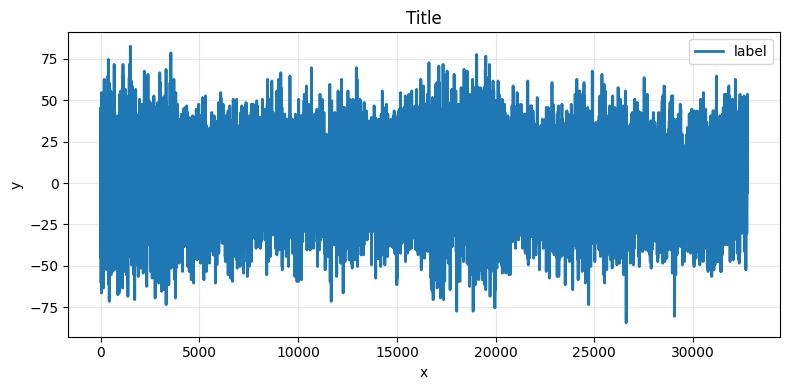

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(samples[1, :], label="label", color="tab:blue", linewidth=2)
plt.title("Title")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 接続を閉じる場合

測定セルを追加している間は接続を維持して構いません。終了時や再接続前には次を実行できます。


In [ ]:
# 必要なときだけ実行する
# if sdr is not None:
#     sdr.close()
#     sdr = None
#     print("Pluto connection: closed")
